# 18 - Train/Test Splits

**Section:** Cross Validation | **Prereqs:** `More on Data/Anatomy_of_DL_TD.ipynb` | **Next:** `Cross Validation/DataLoader.ipynb`

The single most important habit in machine learning: **never evaluate on data
you trained on.** A model with enough capacity can memorise the training set
perfectly and be useless on anything else, and training accuracy cannot tell the
two apart.

**The vocabulary**
- **Train** - the model fits its weights on this.
- **Test / hold-out** - touched once, at the end, to estimate real performance.
- **Devset / validation** - the split you use while tuning hyperparameters, so
  the test set stays uncontaminated. Every time you look at test performance and
  change something, a little of that set's independence is spent.

`train_test_split(..., test_size=0.2)` shuffles and splits in one call. For
imbalanced data add `stratify=target` so the class proportions survive the split.

**What to look for below:** train accuracy climbing above test accuracy. That
gap *is* overfitting, and this notebook is the first place you can see it.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import sklearn.datasets
from sklearn.model_selection import train_test_split



# Using Sklearn

In [ ]:
# Iris again - small enough that overfitting appears within seconds.
iris = sklearn.datasets.load_iris()

df = pd.DataFrame(iris['data'], columns=iris['feature_names'])
df['target'] = iris['target']

In [ ]:
data = df.drop('target',axis=1)
target = df['target']

In [ ]:
# Features float32, labels int64 (CrossEntropyLoss requires long).
data = torch.tensor(data.to_numpy(),dtype=torch.float)
target = torch.tensor(target,dtype=torch.long)

In [ ]:
target = target

In [ ]:
data.shape , target.shape

(torch.Size([150, 4]), torch.Size([150]))

In [ ]:
# 4 -> 64 -> [64 x 3 hidden] -> 3, ReLU throughout, raw logits out.
# Deliberately oversized for 120 training samples: overfitting is the point.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(4,64)

    self.HiddenList = nn.ModuleList()

    for i in range(3):
      self.HiddenList.append(nn.Linear(64,64))

    self.output_layer = nn.Linear(64,3)


  def forward(self,x):

    x = F.relu(self.input_layer(x))


    for hiddenlayer in self.HiddenList:
      x = F.relu(hiddenlayer(x))

    x = self.output_layer(x)

    return x


In [ ]:
# CrossEntropyLoss applies log_softmax internally, so the model must emit raw
# logits (as this one does).
Classifier = model()

lossFunc = nn.CrossEntropyLoss() # Has logorithimic softmax in it
lr = 0.002
epochs = 10000
optimizer = torch.optim.SGD(Classifier.parameters(), lr = lr)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.002
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [ ]:
# The split happens ONCE, outside the loop - 80% train, 20% test.
# Splitting inside the loop would let the model see every sample eventually,
# which quietly destroys the whole point of a hold-out set.
#
# Both accuracies are recorded every epoch: train from the same forward pass
# used for the update, test from a fresh forward pass on unseen data.
# (That test pass builds an autograd graph it does not need; torch.no_grad()
# around it would be faster - see the FNNs notebooks for the tidy version.)
losses = torch.zeros(epochs)
test_accuracy = torch.zeros(epochs)
train_accuracy = torch.zeros(epochs)

data_train , data_test ,target_train, target_test = train_test_split(data,target,test_size=0.2)


for epoch in range(epochs):

  yhat = Classifier.forward(data_train)

  loss = lossFunc(yhat, target_train)
  losses[epoch] = loss

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  train_accuracy[epoch] = 100*torch.mean(((torch.argmax(yhat,axis=1)) == target_train).float())
  test_accuracy[epoch] = 100*torch.mean(((torch.argmax(Classifier(data_test),axis=1)) == target_test).float())

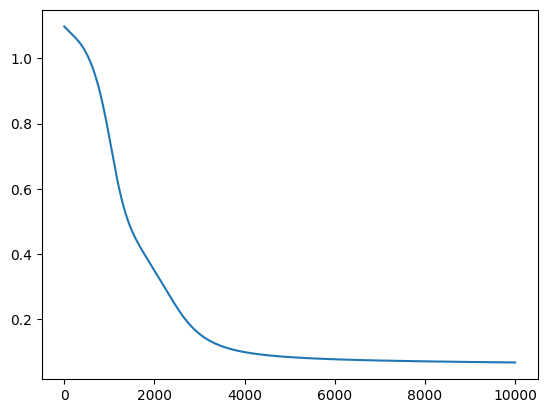

In [ ]:
# Loss on the training set. It keeps falling. On its own it proves nothing.
plt.plot(losses.detach());

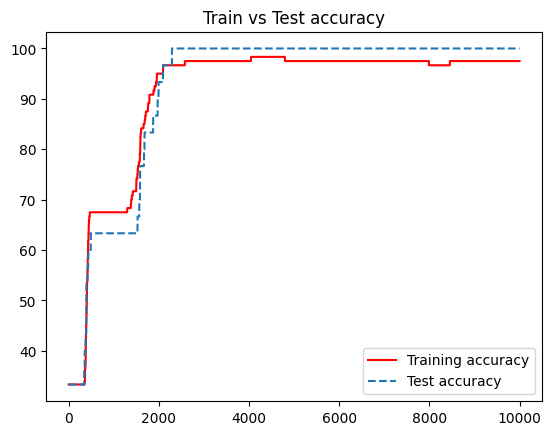

In [ ]:
# The plot that matters. Train (solid) rises above test (dashed) and the gap
# widens: the model is learning things true of these 120 flowers but not of
# flowers in general.
# The epoch where the test curve stops improving is where you should have
# stopped training - that idea becomes early stopping.
plt.plot(train_accuracy, "r-", label="Training accuracy")
plt.plot(test_accuracy, '--', label="Test accuracy")
plt.title("Train vs Test accuracy")
plt.legend();